# H5 — Response Time Analysis

Simple paired t-tests for boundary cost in RT.

Main idea: RT may be higher at Post boundary.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'/home/achyutananda-sahoo/Desktop/IIITH-BRSM/PROJECT/DATA/compiled_preprocessed.csv')
df = df[df['trial_type'].isin(['Target', 'Lure']) & df['RT'].notna()].copy()
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [3]:
rt = (
    df.groupby(['participant_id', 'condition', 'boundary_position'])['RT']
    .mean()
    .reset_index()
)
rt['id'] = rt['condition'] + '_' + rt['participant_id'].astype(int).astype(str)
wide = rt.pivot(index='id', columns='boundary_position', values='RT').dropna()

print('Complete participants:', len(wide))
display(wide[['Pre', 'Mid', 'Post']].mean().to_frame('mean_RT').T)

Complete participants: 158


boundary_position,Pre,Mid,Post
mean_RT,2.373672,2.444437,2.407293


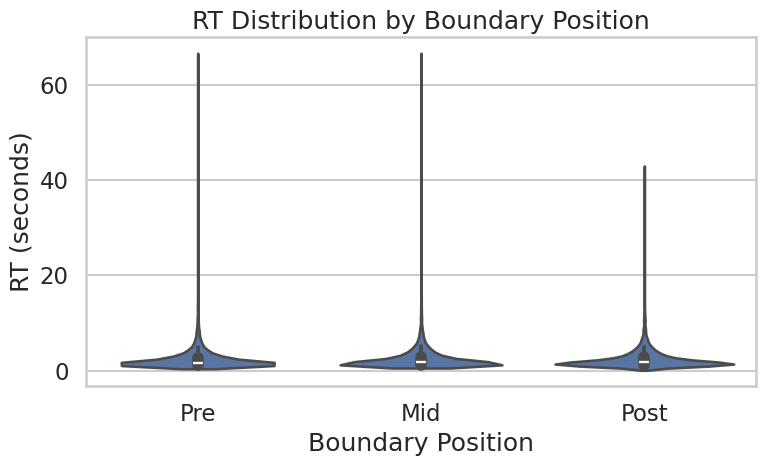

In [4]:
# Visualization: RT distribution by boundary position
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='boundary_position', y='RT', order=['Pre', 'Mid', 'Post'], inner='box', cut=0)
plt.title('RT Distribution by Boundary Position')
plt.xlabel('Boundary Position')
plt.ylabel('RT (seconds)')
plt.tight_layout()
plt.show()

In [5]:
tests = []
for a, b in [('Post', 'Mid'), ('Post', 'Pre')]:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'{a} > {b}',
        'mean_diff_seconds': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_df = pd.DataFrame(tests)
display(result_df)

,comparison,mean_diff_seconds,t_stat,p_value,supported (p<.05)
0,Post > Mid,-0.037144,-0.902516,0.815917,False
1,Post > Pre,0.033622,0.933077,0.176107,False


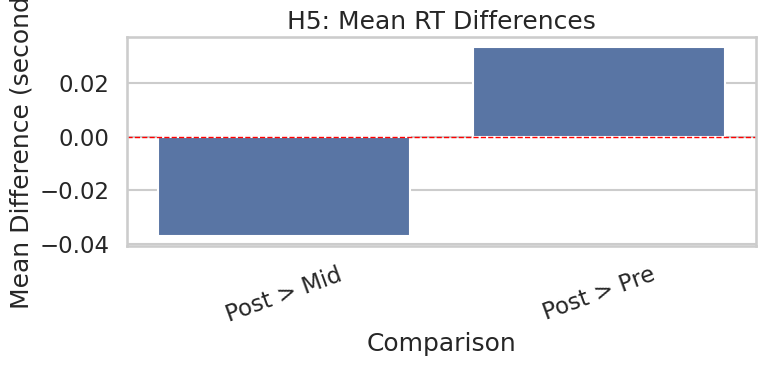

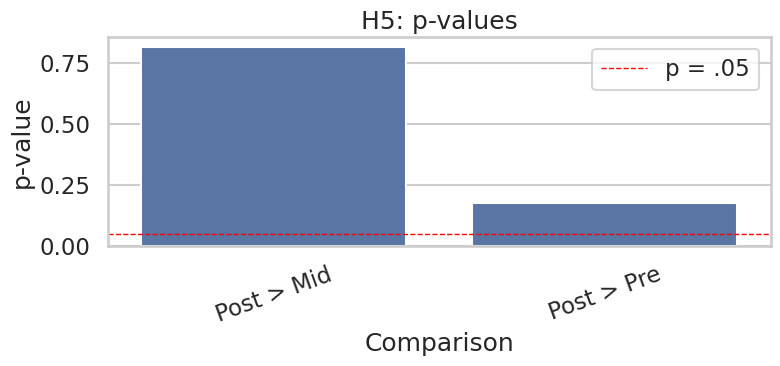

In [6]:
# Visualization: mean RT difference and p-values
plot_df = result_df.copy()

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='comparison', y='mean_diff_seconds')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('H5: Mean RT Differences')
plt.xlabel('Comparison')
plt.ylabel('Mean Difference (seconds)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='comparison', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H5: p-values')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()